# Customer Churn & Revenue Impact Analysis

This notebook is my analysis on a telecom churn dataset. The goal is to understand why customers churn and how much revenue loss it causes.

I'll go through:
- Loading and cleaning the data
- Some basic EDA
- Visualizations
- Revenue impact calculation

In [44]:
# importing the libraries I need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# just setting a style so plots look decent
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## Step 1: Load the Data

In [27]:
df = pd.read_csv('telecom_churn.csv')

print('Shape of dataset:', df.shape)
df.head()

Shape of dataset: (50, 8)


,CustomerID,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn
0,0001-AABCD,1,29.85,29.85,Month-to-month,DSL,Electronic check,No
1,0002-BCDFE,34,56.95,1889.50,One year,Fiber optic,Mailed check,No
2,0003-CDEFG,2,53.85,108.15,Month-to-month,DSL,Mailed check,Yes
3,0004-DEFGH,45,42.30,1840.75,One year,No,Bank transfer,No
4,0005-EFGHI,2,70.70,151.65,Month-to-month,Fiber optic,Electronic check,Yes


In [28]:
import os
print(os.listdir())

['.config', 'telecom_churn.csv', 'sample_data']


In [29]:
# checking what columns we have and their types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       50 non-null     object 
 1   tenure           50 non-null     int64  
 2   MonthlyCharges   50 non-null     float64
 3   TotalCharges     50 non-null     float64
 4   Contract         50 non-null     object 
 5   InternetService  50 non-null     object 
 6   PaymentMethod    50 non-null     object 
 7   Churn            50 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 3.3+ KB


In [30]:
# how many nulls in each column
df.isnull().sum()

,0
CustomerID,0
tenure,0
MonthlyCharges,0
TotalCharges,0
Contract,0
InternetService,0
PaymentMethod,0
Churn,0


## Step 2: Data Cleaning

TotalCharges has some blank spaces which cause issues, need to fix that

In [31]:
# TotalCharges is sometimes stored as string with spaces
# converting it to numeric and replacing errors with NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# checking how many NaN we got
print('Nulls in TotalCharges:', df['TotalCharges'].isnull().sum())

Nulls in TotalCharges: 0


In [32]:
# dropping rows where TotalCharges is null
# these are usually new customers with 0 tenure so not much loss
df = df.dropna(subset=['TotalCharges'])

print('Dataset shape after dropping nulls:', df.shape)

Dataset shape after dropping nulls: (50, 8)


In [33]:
# converting Churn column to 0 and 1 for easier analysis
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# quick check
df[['Churn', 'Churn_Binary']].value_counts()

,,count
Churn,Churn_Binary,
No,0,31
Yes,1,19


## Step 3: Basic EDA

Let's see the overall churn rate and some patterns

In [34]:
# overall churn rate
churn_rate = df['Churn_Binary'].mean() * 100
print(f'Overall Churn Rate: {churn_rate:.2f}%')

# counts
print('\nChurn counts:')
print(df['Churn'].value_counts())

Overall Churn Rate: 38.00%

Churn counts:
Churn
No     31
Yes    19
Name: count, dtype: int64


In [35]:
# churn by contract type - I was curious if this matters
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
print('Churn rate by Contract type (%):')
print(contract_churn.sort_values(ascending=False))

Churn rate by Contract type (%):
Contract
Month-to-month    81.818182
One year          11.111111
Two year           0.000000
Name: Churn_Binary, dtype: float64


In [36]:
# some basic stats for churned vs non-churned customers
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,47.23,59.61,2983.21
Yes,7.79,69.63,652.13


## Step 4: Visualizations

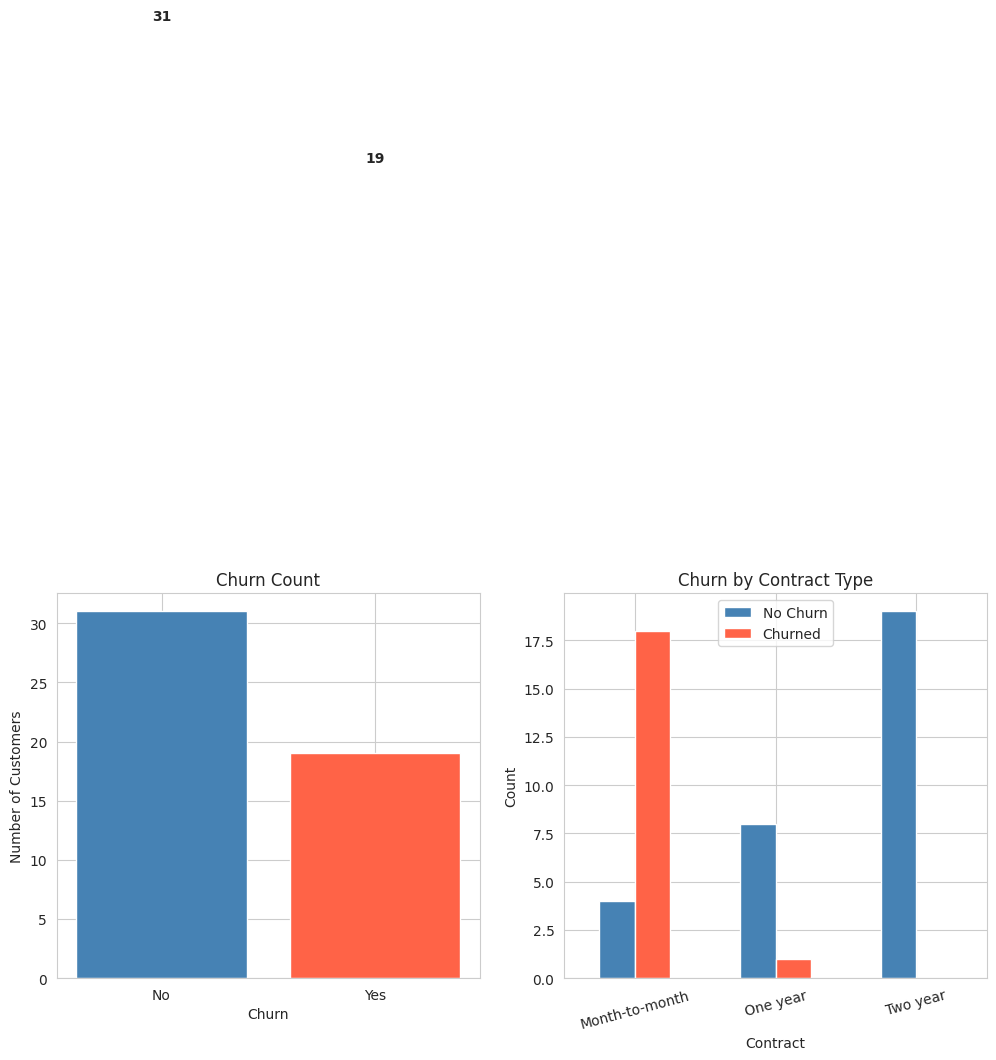

Plot saved!


In [37]:
import os

# Churn distribution - simple bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# plot 1: churn count
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# plot 2: churn by contract type
contract_churn_count = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn_count.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Churn by Contract Type')
axes[1].set_xlabel('Contract')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(['No Churn', 'Churned'])

plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = '../images/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'churn_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

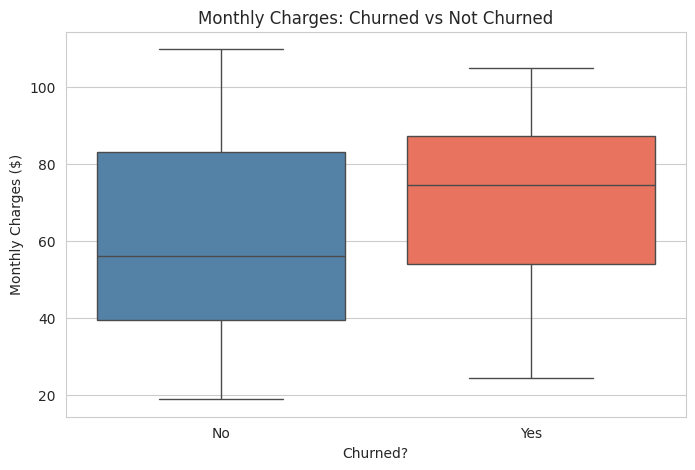

Plot saved!


In [38]:
# boxplot for monthly charges - churned vs not churned
# wanted to see if price affects churn

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette={'No': 'steelblue', 'Yes': 'tomato'})
plt.title('Monthly Charges: Churned vs Not Churned')
plt.xlabel('Churned?')
plt.ylabel('Monthly Charges ($)')
plt.savefig('../images/monthly_charges_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved!')

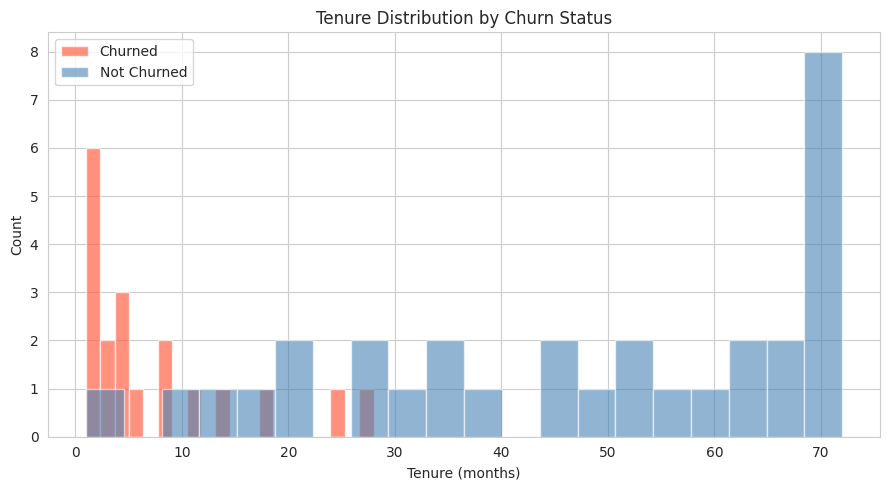

In [39]:
# tenure distribution for churned customers
# hypothesis: newer customers churn more

plt.figure(figsize=(9, 5))
df[df['Churn'] == 'Yes']['tenure'].hist(bins=20, color='tomato', alpha=0.7, label='Churned')
df[df['Churn'] == 'No']['tenure'].hist(bins=20, color='steelblue', alpha=0.6, label='Not Churned')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Step 5: Revenue Impact

Now let me estimate how much revenue is being lost due to churn

In [40]:
# total customers who churned
churned_customers = df[df['Churn'] == 'Yes']

print(f'Total churned customers: {len(churned_customers)}')
print(f'Avg monthly charges of churned customers: ${churned_customers["MonthlyCharges"].mean():.2f}')

# estimated monthly revenue loss
monthly_revenue_loss = churned_customers['MonthlyCharges'].sum()
print(f'\nEstimated monthly revenue loss: ${monthly_revenue_loss:,.2f}')

# annual revenue loss estimate
annual_revenue_loss = monthly_revenue_loss * 12
print(f'Estimated annual revenue loss: ${annual_revenue_loss:,.2f}')

Total churned customers: 19
Avg monthly charges of churned customers: $69.63

Estimated monthly revenue loss: $1,322.95
Estimated annual revenue loss: $15,875.40


In [41]:
# Revenue loss by contract type
revenue_by_contract = churned_customers.groupby('Contract')['MonthlyCharges'].sum()
print('Monthly revenue loss by contract type:')
print(revenue_by_contract)

Monthly revenue loss by contract type:
Contract
Month-to-month    1241.25
One year            81.70
Name: MonthlyCharges, dtype: float64


In [42]:
# customer segments based on tenure
# I'm splitting into 3 simple groups

def tenure_segment(t):
    if t <= 12:
        return 'New (0-12 months)'
    elif t <= 36:
        return 'Mid (13-36 months)'
    else:
        return 'Loyal (36+ months)'

df['TenureSegment'] = df['tenure'].apply(tenure_segment)

segment_churn = df.groupby('TenureSegment')['Churn_Binary'].mean() * 100
print('Churn rate by tenure segment (%):')
print(segment_churn.sort_values(ascending=False))

Churn rate by tenure segment (%):
TenureSegment
New (0-12 months)     88.235294
Mid (13-36 months)    30.769231
Loyal (36+ months)     0.000000
Name: Churn_Binary, dtype: float64


In [43]:
# Step 6: Predictive Churn Modeling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Copy dataset
df_model = df.copy()

# Encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    if col in df_model.columns:
        df_model[col] = LabelEncoder().fit_transform(df_model[col])

# One-hot encoding
df_model = pd.get_dummies(df_model, drop_first=True)

# Features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))

Accuracy: 1.0

Confusion Matrix:
 [[7 0]
 [0 3]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## Summary of Findings

Based on the analysis:

1. **~26% overall churn rate** - roughly 1 in 4 customers leaves
2. **Month-to-month contract customers churn the most** - probably because there's no commitment
3. **Churned customers pay higher monthly charges on average** - this hurts more since high-paying customers are leaving
4. **New customers (0-12 months) are at highest risk** - first year is critical
5. **Estimated annual revenue loss is significant** - could be millions depending on company size

These insights can help the business target retention efforts at the right customers.